# 🛒 Market Basket Analysis using Apriori Algorithm
### 🔍 Association Rule Mining on Grocery Transaction Data

## 📌 Introduction

Market Basket Analysis is a powerful **data mining technique** used to discover relationships between products that customers frequently purchase together. It helps businesses understand purchasing behavior and uncover hidden patterns in transactional data.

In this project, we perform **Association Rule Mining using the Apriori Algorithm** to analyze a grocery store dataset and identify meaningful relationships between products.

Understanding these relationships can help businesses:

✔ Improve product placement in stores  
✔ Design better cross-selling strategies  
✔ Create product bundle offers  
✔ Build recommendation systems  

---

## 📊 Dataset Description

The dataset contains grocery store transactions where each row represents items purchased together in a single transaction.

Example products in the dataset include:

- 🥖 Bread  
- ☕ Coffee  
- 🍪 Biscuit  
- 🍵 Tea  
- 🥛 Milk  
- 🥣 Cornflakes  
- 🍜 Maggi  
- 🧂 Sugar  
- 🥤 Coke  
- 🍫 Bournvita  
- 🍓 Jam  

Each transaction contains a combination of these items purchased by customers.

---

## ⚙️ Techniques Used

This project applies several data mining techniques:

🔹 Transaction Encoding  
🔹 Frequent Itemset Mining  
🔹 Apriori Algorithm  
🔹 Association Rule Generation  

These techniques help uncover hidden patterns in transactional datasets.

---

## 🧰 Libraries Used

The following Python libraries were used in this project:

- 📦 pandas  
- 🔢 numpy  
- 📊 matplotlib  
- 📈 seaborn  
- ⚡ mlxtend  

---

## 🔄 Project Workflow

1️⃣ Load and explore the dataset  
2️⃣ Preprocess the transaction data  
3️⃣ Convert transactions into encoded format using TransactionEncoder  
4️⃣ Calculate item frequencies  
5️⃣ Generate frequent itemsets using the Apriori Algorithm  
6️⃣ Create association rules using confidence metrics  
7️⃣ Analyze relationships between products  

This analysis helps understand **which products are commonly purchased together**, enabling businesses to make **data-driven retail decisions**.

In [1]:
# Import Neccesary libraries
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset

df=pd.read_csv(r"GroceryStoreDataSet.csv",header=None,names=["product"])
df

,product
0,"MILK,BREAD,BISCUIT"
1,"BREAD,MILK,BISCUIT,CORNFLAKES"
2,"BREAD,TEA,BOURNVITA"
3,"JAM,MAGGI,BREAD,MILK"
4,"MAGGI,TEA,BISCUIT"
5,"BREAD,TEA,BOURNVITA"
6,"MAGGI,TEA,CORNFLAKES"
7,"MAGGI,BREAD,TEA,BISCUIT"
8,"JAM,MAGGI,BREAD,TEA"
9,"BREAD,MILK"


In [3]:
df.shape

(20, 1)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   product  20 non-null     str  
dtypes: str(1)
memory usage: 710.0 bytes


In [5]:
df.values

array([['MILK,BREAD,BISCUIT'],
       ['BREAD,MILK,BISCUIT,CORNFLAKES'],
       ['BREAD,TEA,BOURNVITA'],
       ['JAM,MAGGI,BREAD,MILK'],
       ['MAGGI,TEA,BISCUIT'],
       ['BREAD,TEA,BOURNVITA'],
       ['MAGGI,TEA,CORNFLAKES'],
       ['MAGGI,BREAD,TEA,BISCUIT'],
       ['JAM,MAGGI,BREAD,TEA'],
       ['BREAD,MILK'],
       ['COFFEE,COKE,BISCUIT,CORNFLAKES'],
       ['COFFEE,COKE,BISCUIT,CORNFLAKES'],
       ['COFFEE,SUGER,BOURNVITA'],
       ['BREAD,COFFEE,COKE'],
       ['BREAD,SUGER,BISCUIT'],
       ['COFFEE,SUGER,CORNFLAKES'],
       ['BREAD,SUGER,BOURNVITA'],
       ['BREAD,COFFEE,SUGER'],
       ['BREAD,COFFEE,SUGER'],
       ['TEA,MILK,COFFEE,CORNFLAKES']], dtype=object)

In [6]:
data = list(df["product"].apply(lambda x:x.split(',')))
data

[['MILK', 'BREAD', 'BISCUIT'],
 ['BREAD', 'MILK', 'BISCUIT', 'CORNFLAKES'],
 ['BREAD', 'TEA', 'BOURNVITA'],
 ['JAM', 'MAGGI', 'BREAD', 'MILK'],
 ['MAGGI', 'TEA', 'BISCUIT'],
 ['BREAD', 'TEA', 'BOURNVITA'],
 ['MAGGI', 'TEA', 'CORNFLAKES'],
 ['MAGGI', 'BREAD', 'TEA', 'BISCUIT'],
 ['JAM', 'MAGGI', 'BREAD', 'TEA'],
 ['BREAD', 'MILK'],
 ['COFFEE', 'COKE', 'BISCUIT', 'CORNFLAKES'],
 ['COFFEE', 'COKE', 'BISCUIT', 'CORNFLAKES'],
 ['COFFEE', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'COKE'],
 ['BREAD', 'SUGER', 'BISCUIT'],
 ['COFFEE', 'SUGER', 'CORNFLAKES'],
 ['BREAD', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'SUGER'],
 ['BREAD', 'COFFEE', 'SUGER'],
 ['TEA', 'MILK', 'COFFEE', 'CORNFLAKES']]

In [7]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install numpy --upgrade

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
np.__version__

'2.4.2'

In [10]:
from mlxtend.preprocessing import TransactionEncoder

In [11]:
te = TransactionEncoder()
te_data = te.fit(data).transform(data)
df = pd.DataFrame(te_data,columns=te.columns_)
df

,BISCUIT,BOURNVITA,BREAD,COFFEE,COKE,CORNFLAKES,JAM,MAGGI,MILK,SUGER,TEA
0,True,False,True,False,False,False,False,False,True,False,False
1,True,False,True,False,False,True,False,False,True,False,False
2,False,True,True,False,False,False,False,False,False,False,True
3,False,False,True,False,False,False,True,True,True,False,False
4,True,False,False,False,False,False,False,True,False,False,True
5,False,True,True,False,False,False,False,False,False,False,True
6,False,False,False,False,False,True,False,True,False,False,True
7,True,False,True,False,False,False,False,True,False,False,True
8,False,False,True,False,False,False,True,True,False,False,True
9,False,False,True,False,False,False,False,False,True,False,False


In [12]:
df.sum()

BISCUIT        7
BOURNVITA      4
BREAD         13
COFFEE         8
COKE           3
CORNFLAKES     6
JAM            2
MAGGI          5
MILK           5
SUGER          6
TEA            7
dtype: int64

In [13]:
df.sum().to_frame()

,0
BISCUIT,7
BOURNVITA,4
BREAD,13
COFFEE,8
COKE,3
CORNFLAKES,6
JAM,2
MAGGI,5
MILK,5
SUGER,6


<Axes: title={'center': 'Frequent Items'}>

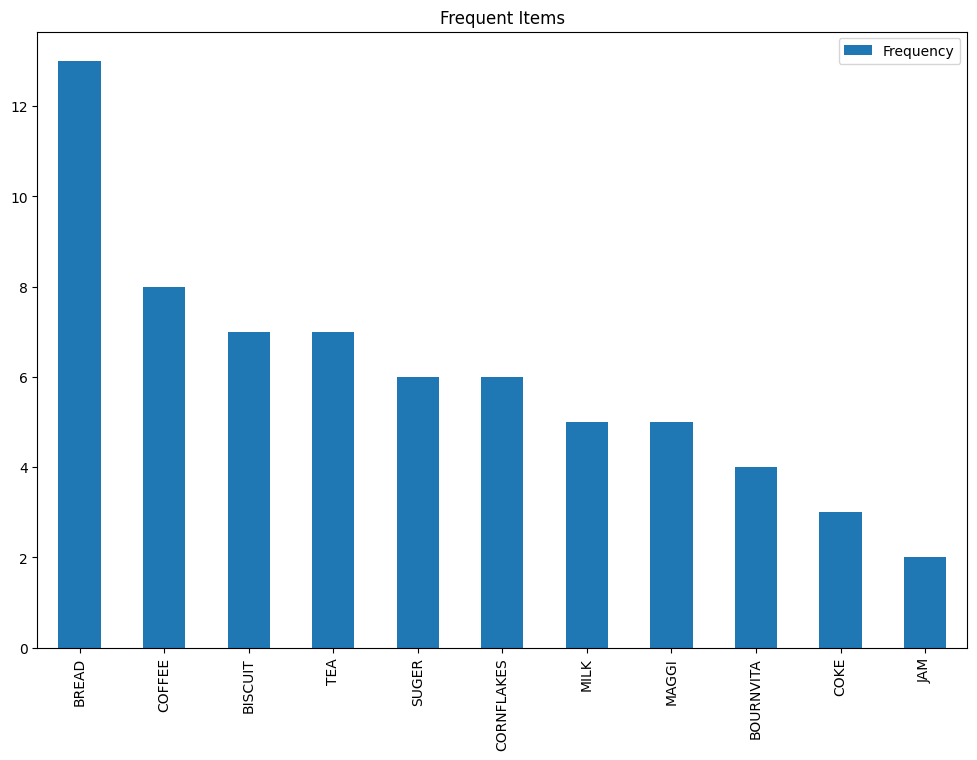

In [14]:
df.sum().to_frame('Frequency').sort_values('Frequency',ascending=False).plot(kind='bar',figsize=(12,8),
                                                                            title="Frequent Items")

In [15]:
df.shape[0]

20

In [16]:
# Product Frequency / Total Sales

first = pd.DataFrame(df.sum() / df.shape[0],columns = ["Support"]).sort_values("Support", ascending=False)
first

,Support
BREAD,0.65
COFFEE,0.40
BISCUIT,0.35
TEA,0.35
SUGER,0.30
CORNFLAKES,0.30
MILK,0.25
MAGGI,0.25
BOURNVITA,0.20
COKE,0.15


In [17]:
first[first.Support>0.30]

,Support
BREAD,0.65
COFFEE,0.40
BISCUIT,0.35
TEA,0.35


In [18]:
import itertools

In [19]:
second = list(itertools.combinations(first.index,3))
second = [list(i) for i in second]
# Sample of combination
second

[['BREAD', 'COFFEE', 'BISCUIT'],
 ['BREAD', 'COFFEE', 'TEA'],
 ['BREAD', 'COFFEE', 'SUGER'],
 ['BREAD', 'COFFEE', 'CORNFLAKES'],
 ['BREAD', 'COFFEE', 'MILK'],
 ['BREAD', 'COFFEE', 'MAGGI'],
 ['BREAD', 'COFFEE', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'COKE'],
 ['BREAD', 'COFFEE', 'JAM'],
 ['BREAD', 'BISCUIT', 'TEA'],
 ['BREAD', 'BISCUIT', 'SUGER'],
 ['BREAD', 'BISCUIT', 'CORNFLAKES'],
 ['BREAD', 'BISCUIT', 'MILK'],
 ['BREAD', 'BISCUIT', 'MAGGI'],
 ['BREAD', 'BISCUIT', 'BOURNVITA'],
 ['BREAD', 'BISCUIT', 'COKE'],
 ['BREAD', 'BISCUIT', 'JAM'],
 ['BREAD', 'TEA', 'SUGER'],
 ['BREAD', 'TEA', 'CORNFLAKES'],
 ['BREAD', 'TEA', 'MILK'],
 ['BREAD', 'TEA', 'MAGGI'],
 ['BREAD', 'TEA', 'BOURNVITA'],
 ['BREAD', 'TEA', 'COKE'],
 ['BREAD', 'TEA', 'JAM'],
 ['BREAD', 'SUGER', 'CORNFLAKES'],
 ['BREAD', 'SUGER', 'MILK'],
 ['BREAD', 'SUGER', 'MAGGI'],
 ['BREAD', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'SUGER', 'COKE'],
 ['BREAD', 'SUGER', 'JAM'],
 ['BREAD', 'CORNFLAKES', 'MILK'],
 ['BREAD', 'CORNFLAKES', 'MAGGI'],
 [

In [20]:
from mlxtend.frequent_patterns import apriori

In [21]:
df1 = apriori(df,min_support=0.001, use_colnames=True)
df1[df1.support>0.10]

,support,itemsets
0,0.35,frozenset({BISCUIT})
1,0.20,frozenset({BOURNVITA})
2,0.65,frozenset({BREAD})
3,0.40,frozenset({COFFEE})
4,0.15,frozenset({COKE})
5,0.30,frozenset({CORNFLAKES})
7,0.25,frozenset({MAGGI})
8,0.25,frozenset({MILK})
9,0.30,frozenset({SUGER})
10,0.35,frozenset({TEA})


In [22]:
df1.head(20).sort_values(by='support',ascending=False)

,support,itemsets
2,0.65,frozenset({BREAD})
3,0.40,frozenset({COFFEE})
0,0.35,frozenset({BISCUIT})
10,0.35,frozenset({TEA})
9,0.30,frozenset({SUGER})
5,0.30,frozenset({CORNFLAKES})
8,0.25,frozenset({MILK})
7,0.25,frozenset({MAGGI})
1,0.20,frozenset({BOURNVITA})
11,0.20,"frozenset({BREAD, BISCUIT})"


In [23]:
df1['length'] = df1['itemsets'].apply(lambda x:len(x))
df1

,support,itemsets,length
0,0.35,frozenset({BISCUIT}),1
1,0.20,frozenset({BOURNVITA}),1
2,0.65,frozenset({BREAD}),1
3,0.40,frozenset({COFFEE}),1
4,0.15,frozenset({COKE}),1
...,...,...,...
78,0.05,"frozenset({BREAD, BISCUIT, MAGGI, TEA})",4
79,0.10,"frozenset({CORNFLAKES, BISCUIT, COFFEE, COKE})",4
80,0.05,"frozenset({BREAD, JAM, MAGGI, MILK})",4
81,0.05,"frozenset({BREAD, JAM, MAGGI, TEA})",4


In [24]:
df1[(df1['length']==4) & (df1['support']>0.05)]

,support,itemsets,length
79,0.1,"frozenset({CORNFLAKES, BISCUIT, COFFEE, COKE})",4


In [25]:
from mlxtend.frequent_patterns import association_rules

In [26]:
df_ar = association_rules(df1, metric = "confidence", min_threshold = 0.2)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({BREAD}),frozenset({BISCUIT}),0.65,0.35,0.20,0.307692,0.879121,1.0,-0.0275,0.938889,-0.282051,0.250000,-0.065089,0.439560
1,frozenset({BISCUIT}),frozenset({BREAD}),0.35,0.65,0.20,0.571429,0.879121,1.0,-0.0275,0.816667,-0.174603,0.250000,-0.224490,0.439560
2,frozenset({BISCUIT}),frozenset({COFFEE}),0.35,0.40,0.10,0.285714,0.714286,1.0,-0.0400,0.840000,-0.380952,0.153846,-0.190476,0.267857
3,frozenset({COFFEE}),frozenset({BISCUIT}),0.40,0.35,0.10,0.250000,0.714286,1.0,-0.0400,0.866667,-0.400000,0.153846,-0.153846,0.267857
4,frozenset({BISCUIT}),frozenset({COKE}),0.35,0.15,0.10,0.285714,1.904762,1.0,0.0475,1.190000,0.730769,0.250000,0.159664,0.476190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,"frozenset({CORNFLAKES, TEA})","frozenset({COFFEE, MILK})",0.10,0.05,0.05,0.500000,10.000000,1.0,0.0450,1.900000,1.000000,0.500000,0.473684,0.750000
260,"frozenset({COFFEE, MILK})","frozenset({CORNFLAKES, TEA})",0.05,0.10,0.05,1.000000,10.000000,1.0,0.0450,inf,0.947368,0.500000,1.000000,0.750000
261,"frozenset({COFFEE, TEA})","frozenset({CORNFLAKES, MILK})",0.05,0.10,0.05,1.000000,10.000000,1.0,0.0450,inf,0.947368,0.500000,1.000000,0.750000
262,"frozenset({MILK, TEA})","frozenset({CORNFLAKES, COFFEE})",0.05,0.20,0.05,1.000000,5.000000,1.0,0.0400,inf,0.842105,0.250000,1.000000,0.625000


# ✅ Conclusion & Results

This project successfully applied **Association Rule Mining using the Apriori Algorithm** to analyze grocery store transaction data and identify relationships between frequently purchased items.

The analysis revealed important insights about **customer purchasing patterns**.

---

## 📊 Key Findings

🔹 **Bread** was the most frequently purchased product with the highest support value.

🔹 Other frequently purchased items included:

- ☕ Coffee  
- 🍪 Biscuit  
- 🍵 Tea  
- 🧂 Sugar  
- 🥣 Cornflakes  

---

## 🔗 Strong Product Associations

The Apriori algorithm discovered several meaningful associations between items, including:

✔ Bread → Biscuit  
✔ Coffee → Biscuit  
✔ Coffee → Cornflakes  
✔ Tea → Maggi  
✔ Bread → Sugar  

These relationships indicate that customers frequently purchase these items together.

---

## 💡 Business Insights

Using these insights, businesses can:

📍 Place frequently purchased products close to each other  
📦 Create combo offers and product bundles  
📈 Improve cross-selling strategies  
🛒 Enhance recommendation systems  

---

## 🎯 Final Outcome

The project demonstrates how **Market Basket Analysis** can uncover hidden product relationships in transactional data.

Such insights are widely used in:

- 🏬 Retail analytics  
- 🛍 E-commerce recommendation systems  
- 📊 Customer behavior analysis  
- 📈 Sales optimization strategies  

By leveraging **Association Rule Mining**, businesses can make smarter decisions that improve customer experience and increase revenue.